## Installing Packages

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import copy, math

---

## Getting Familiar with Dataset

### View the variables

In [13]:
def load_data():
    data = np.loadtxt("ex1data1.txt", delimiter=',')
    X = data[:,0]
    y = data[:,1]
    return X, y

x_train, y_train = load_data() #load the dataset
print("Type of x_train: ", type(x_train))
print("First 5 elements of x_train: \n", x_train[:5])

Type of x_train:  <class 'numpy.ndarray'>
First 5 elements of x_train: 
 [6.1101 5.5277 8.5186 7.0032 5.8598]


These values represent the city population times 10,000. For example, 6.1101 means that the population for that city is 61,101

In [14]:
print("Type of y_train: ",type(y_train))
print("First five elements of y_train: \n", y_train[:5])

Type of y_train:  <class 'numpy.ndarray'>
First five elements of y_train: 
 [17.592   9.1302 13.662  11.854   6.8233]


These represent your restaurant's average monthly profits in each city, in units of \$10,000.
- For example, 17.592 represents \$175,920 in average monthly profits for that city. 
- -2.6807 represents -\$26,807 in average monthly loss for that city.

### Checking the dimensions

In [15]:
print('The shape of x_train:', x_train.shape)
print('The shape of y_train : ', y_train.shape)
print('Number of training examples (m):', len(x_train))

The shape of x_train: (97,)
The shape of y_train :  (97,)
Number of training examples (m): 97


The city population array has 97 data points, and the monthly average profits also has 97 data points. These are NumPy 1D arrays.

### Visualizing the data

We can use scatter plot since it has only two properties to plot (profit and population)

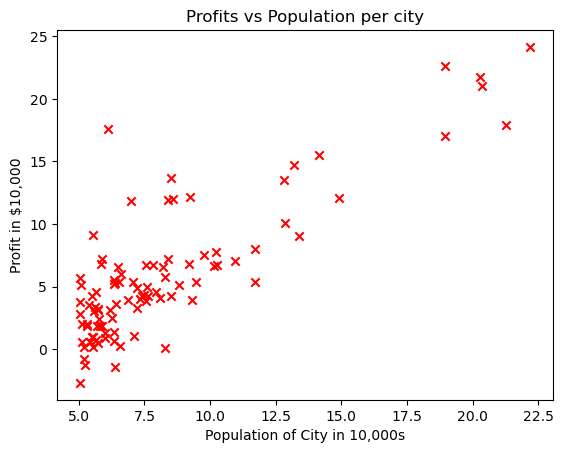

In [16]:
plt.scatter(x_train, y_train, marker = 'x', c = 'r')
plt.title("Profits vs Population per city")
plt.ylabel('Profit in $10,000')
plt.xlabel('Population of City in 10,000s')
plt.show()

---

## Compute cost function
The prediction of the model for that example 
    $$
    f_{wb}(x^{(i)}) =  wx^{(i)} + b 
    $$
   
The cost for that example  $$cost^{(i)} =  (f_{wb} - y^{(i)})^2$$

The total cost over all examples
$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} cost^{(i)}$$
Here, $m$ is the number of training examples

In [17]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    total_cost = 0
    cost_sum = 0
    for i in range(m):
        f = w*x[i]+b
        cost = (f-y[i])**2
        cost_sum += cost
    total_cost = (1/(2*m))*cost_sum
    return total_cost

---

## Gradient Descent
The prediction of the model for that example 
    $$
    f_{wb}(x^{(i)}) =  wx^{(i)} + b 
    $$
   
The gradient for the parameters $w, b$ from that example 
        $$
        \frac{\partial J(w,b)}{\partial b}^{(i)}  =  (f_{w,b}(x^{(i)}) - y^{(i)}) 
        $$
        $$
        \frac{\partial J(w,b)}{\partial w}^{(i)}  =  (f_{w,b}(x^{(i)}) -y^{(i)})x^{(i)} 
        $$
    

The total gradient update from all the examples
    $$
    \frac{\partial J(w,b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} \frac{\partial J(w,b)}{\partial b}^{(i)}
    $$
    
$$
    \frac{\partial J(w,b)}{\partial w}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} \frac{\partial J(w,b)}{\partial w}^{(i)} 
    $$
Here, $m$ is the number of training examples

### Defining the compute gradient function

In [18]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0; dj_db = 0

    for i in range(m):
        f = w*x[i]+b
        dj_dw_i = (f-y[i])*x[i]
        dj_db_i = f-y[i]
        dj_dw += dj_dw_i
        dj_db += dj_db_i

    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

### Implementing the Gradient Descent

Here,
- w_in, b_in : (scalar) Initial values of parameters of the model
- cost_function: function to compute cost
- gradient_function: function to compute the gradient
- alpha : (float) Learning rate
- num_iters : (int) number of iterations to run gradient descent

In [19]:
def gradient_descent(x, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    m = len(x)
    j_history = []; w_history = []    # An array to store cost J and w's at each iteration (for graphing purpose)
    w = copy.deepcopy(w_in)    # To avoid the modification of global w within function
    b = b_in

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w, b)    # Calculating the gradient
        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        if i<100000:    # Prevent resource exhaustion
            cost = cost_function(x, y, w, b)
            j_history.append(cost)

        if i%math.ceil(num_iters/10) == 0:    # Print cost every at intervals 10 times or as many iterations if < 10
            w_history.append(w)
            print(f"Iteration:  {i:4} | Cost: {float(j_history[-1]):8.2f}  ")

    return w, b, j_history, w_history

### Learning the Parameters in the dataset

In [20]:
init_w = 0.; init_b = 0.

iterations = 1500; alpha = 0.01

w,b,_,_ = gradient_descent(x_train ,y_train, init_w, init_b, compute_cost, compute_gradient, alpha, iterations)
print("w,b found by gradient descent:", w, b)

Iteration:     0 | Cost:     6.74  
Iteration:   150 | Cost:     5.31  
Iteration:   300 | Cost:     4.96  
Iteration:   450 | Cost:     4.76  
Iteration:   600 | Cost:     4.64  
Iteration:   750 | Cost:     4.57  
Iteration:   900 | Cost:     4.53  
Iteration:  1050 | Cost:     4.51  
Iteration:  1200 | Cost:     4.50  
Iteration:  1350 | Cost:     4.49  
w,b found by gradient descent: 1.166362350335582 -3.63029143940436


We will now use the final parameters from gradient descent to plot the linear fit.

---

## Plotting the Final 

To calculate the predictions on the entire dataset, we can loop through all the training examples and calculate the prediction for each example.

In [21]:
m = x_train.shape[0]
predicted = np.zeros(m)

for i in range(m):
    predicted[i] = w*x_train[i] + b

Text(0.5, 0, 'Population of City in 10,000s')

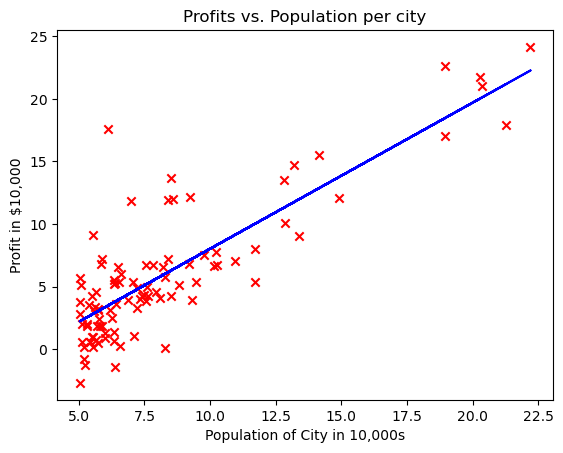

In [22]:
plt.plot(x_train, predicted, c = 'b')
plt.scatter(x_train, y_train, marker='x', c='r') 

plt.title("Profits vs. Population per city")
plt.ylabel('Profit in $10,000')
plt.xlabel('Population of City in 10,000s')

### Sample predictions
Let's predict what the profit would be in areas of 35,000 and 70,000 people. 
- The model takes in population of a city in 10,000s as input. 
- Therefore, 35,000 people can be translated into an input to the model as `np.array([3.5])`
- Similarly, 70,000 people can be translated into an input to the model as `np.array([7.])`

In [41]:
predict1 = 3.5*w+b
print('For population = 35,000, we predict a profit of $%.2f' % (predict1*10000))

predict2 = 7.0*w+b
print('For population = 70,000, we predict a profit of $%.2f' % (predict2*10000))

For population = 35,000, we predict a profit of $4519.77
For population = 70,000, we predict a profit of $45342.45


---